<a href="https://colab.research.google.com/github/ddy623/Kaggle-Projects/blob/main/loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [3]:
# Load Data
fpath = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/loan_approval_dataset.csv'
df = pd.read_csv(fpath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df.columns = df.columns.str.strip()
for col in ['education', 'self_employed', 'loan_status']:
    df[col] = df[col].str.strip()

print("Unique values for 'education':")
print(df['education'].value_counts())
print("\nUnique values for 'self_employed':")
print(df['self_employed'].value_counts())
print("\nUnique values for 'loan_status':")
print(df['loan_status'].value_counts())

Unique values for 'education':
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Unique values for 'self_employed':
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

Unique values for 'loan_status':
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [5]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


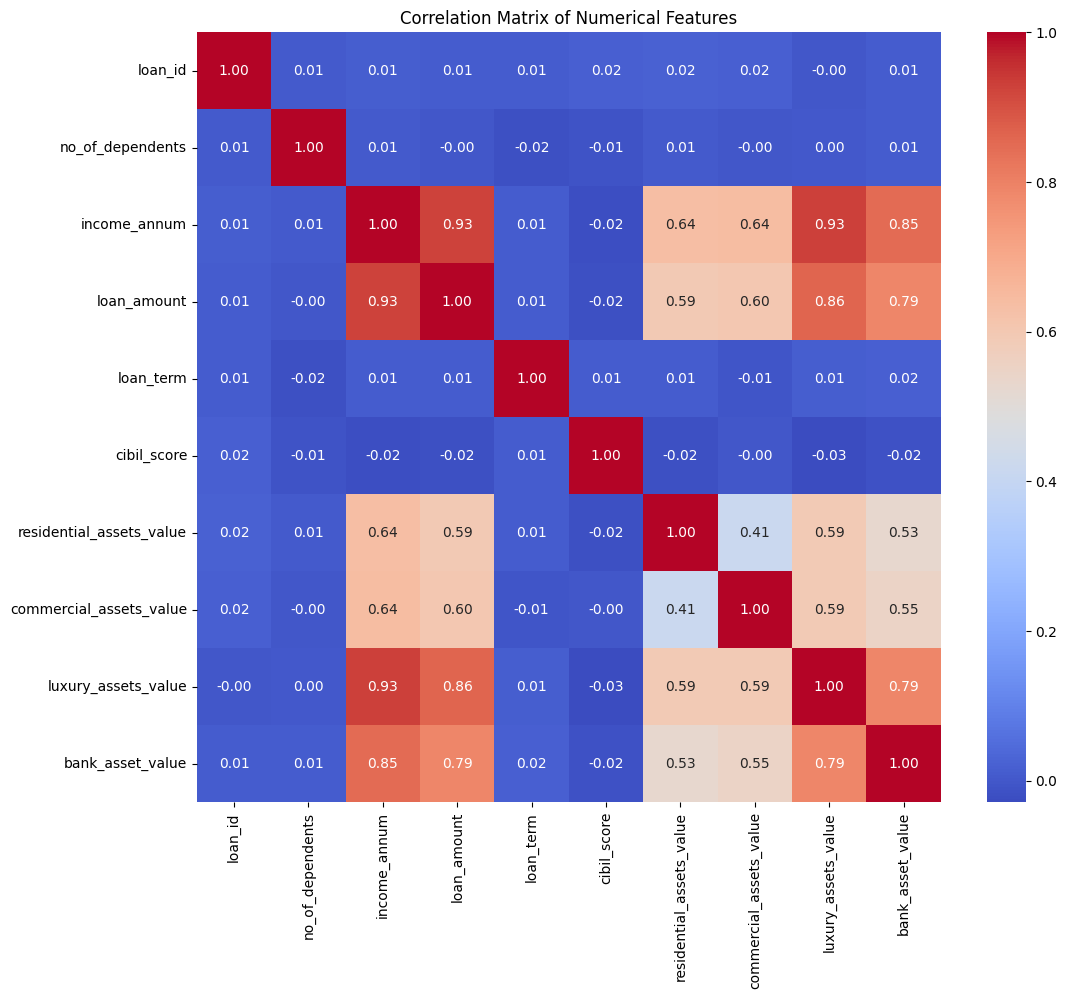

In [6]:


# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [7]:
print('Summary statistics for the DataFrame:')
display(df.describe(include='all'))

Summary statistics for the DataFrame:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


In [8]:
correlation = df['loan_amount'].corr(df['income_annum'])
print(f"Correlation between loan_amount and income_annum: {correlation:.2f}")

Correlation between loan_amount and income_annum: 0.93


In [9]:
correlation_income_bank_asset = df['income_annum'].corr(df['bank_asset_value'])
print(f"Correlation between income_annum and bank_asset_value: {correlation_income_bank_asset:.2f}")

Correlation between income_annum and bank_asset_value: 0.85


In [10]:


# Create a mask to remove the upper triangle and self-correlations
mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)

# Apply the mask to the absolute correlation matrix and unstack
# We take the absolute value as we are interested in the strength of correlation, regardless of direction
abs_correlations = correlation_matrix.abs().where(mask)
stacked_correlations = abs_correlations.stack()

# Sort the correlations in descending order
sorted_correlations = stacked_correlations.sort_values(ascending=False)

# Select the top three unique correlations
top_3_correlations = sorted_correlations.head(3)

print("Top 3 unique absolute correlations:")
print(top_3_correlations)

Top 3 unique absolute correlations:
income_annum  luxury_assets_value    0.929145
              loan_amount            0.927470
loan_amount   luxury_assets_value    0.860914
dtype: float64


# Task
Create a predictive model to classify loan approval status using the data from "loan_approval_dataset.csv". The model should handle categorical features, be trained on a split dataset, and its performance should be evaluated and summarized.

## Preprocess Data

### Subtask:
Convert categorical features like 'education', 'self_employed', and 'loan_status' into numerical representations, and define features (X) and target (y) variables.


**Reasoning**:
To prepare the data for modeling, I need to convert the categorical features 'education', 'self_employed', and 'loan_status' into numerical representations using `LabelEncoder`, and then separate the features (X) from the target variable (y).



In [11]:


# Initialize LabelEncoder for categorical columns
le_education = LabelEncoder()
le_self_employed = LabelEncoder()
le_loan_status = LabelEncoder()

# Apply LabelEncoder to convert categorical features to numerical
df['education'] = le_education.fit_transform(df['education'])
df['self_employed'] = le_self_employed.fit_transform(df['self_employed'])
df['loan_status'] = le_loan_status.fit_transform(df['loan_status'])

# Define features (X) and target (y) variables
X = df.drop(columns=['loan_id', 'loan_status'])
y = df['loan_status']

print("Categorical features converted to numerical, and X, y defined.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:\n", X.head())
print("First 5 values of y:\n", y.head())

Categorical features converted to numerical, and X, y defined.
Shape of X: (4269, 11)
Shape of y: (4269,)
First 5 rows of X:
    no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          0              0       9600000     29900000   
1                 0          1              1       4100000     12200000   
2                 3          0              0       9100000     29700000   
3                 3          0              0       8200000     30700000   
4                 5          1              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20     

## Split Data

### Subtask:
Divide the preprocessed dataset into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
To divide the dataset into training and testing sets, I need to import the `train_test_split` function and apply it to the `X` and `y` variables with the specified parameters.



In [12]:


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets.
Shape of X_train: (3415, 11)
Shape of X_test: (854, 11)
Shape of y_train: (3415,)
Shape of y_test: (854,)


## Train Predictive Model

### Subtask:
Train a classification model (e.g., Logistic Regression or RandomForestClassifier) on the training data to predict 'loan_status'.


**Reasoning**:
To train the classification model as per the instructions, I need to import `LogisticRegression` from `sklearn.linear_model`, instantiate it with `random_state` and `max_iter` for reproducibility and convergence, and then fit the model to the training data.



In [13]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance using appropriate metrics such as accuracy, precision, recall, F1-score, and a confusion matrix, then visualize the confusion matrix for better understanding of the model's predictions.


**Reasoning**:
To evaluate the trained model, I need to make predictions on the test set, calculate performance metrics, and visualize the confusion matrix. I will import the necessary metrics from `sklearn.metrics`, compute them, and then plot the confusion matrix.



Accuracy: 0.7986
Precision: 0.8017
Recall: 0.6101
F1-Score: 0.6929

Confusion Matrix:
 [[488  48]
 [124 194]]


<Figure size 800x600 with 0 Axes>

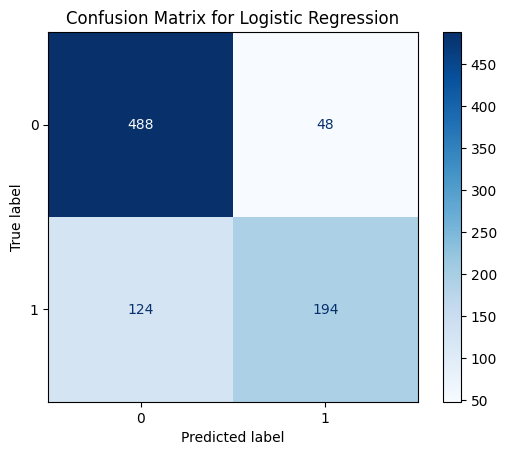

In [14]:


# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the calculated evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Create and display the confusion matrix plot
plt.figure(figsize=(8, 6))
cmd = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
cmd.ax_.set_title('Confusion Matrix for Logistic Regression')
plt.show()

## Final Task

### Subtask:
Summarize the model building process, the chosen model's performance, and potential next steps for improvement.


## Summary:

### Data Analysis Key Findings

*   **Data Preprocessing**: Categorical features 'education', 'self_employed', and 'loan_status' were successfully converted to numerical representations using `LabelEncoder`. The feature set `X` comprised 11 features for 4269 samples, and the target variable `y` represented the 'loan\_status'.
*   **Data Splitting**: The dataset was divided into training and testing sets, with 80% (3415 samples) for training and 20% (854 samples) for testing, ensuring reproducibility with a `random_state` of 42.
*   **Model Training**: A Logistic Regression model was trained on the preprocessed training data (`X_train`, `y_train`) to predict the loan approval status.
*   **Model Performance Evaluation**: The trained Logistic Regression model achieved the following performance on the test set:
    *   **Accuracy**: 0.7986
    *   **Precision**: 0.8017
    *   **Recall**: 0.6101
    *   **F1-Score**: 0.6929
*   **Confusion Matrix Analysis**: The confusion matrix showed the following:
    *   True Negatives (correctly predicted rejections): 488
    *   False Positives (incorrectly predicted approvals): 48
    *   False Negatives (incorrectly predicted rejections): 124
    *   True Positives (correctly predicted approvals): 194

### Insights or Next Steps

*   The current Logistic Regression model exhibits a good overall accuracy (around 80%) but has a lower recall for the positive class (loan approval), indicating that it misses predicting a significant portion of actual loan approvals (124 out of 318 actual approvals were missed). This suggests a potential imbalance in how the model handles approved versus rejected loans.
*   To improve the model's ability to identify loan approvals, consider exploring other classification algorithms (e.g., RandomForest, Gradient Boosting) that might better handle class imbalance, or implement techniques like SMOTE to balance the training data, or adjust the classification threshold.


# Task
I've completed the evaluation of the trained model, which included displaying the confusion matrix.

The confusion matrix for the Logistic Regression model has been displayed, showing the following:
- True Negatives: 488
- False Positives: 48
- False Negatives: 124
- True Positives: 194

This visualization helps understand the model's performance in classifying loan approval status.

## Display Confusion Matrix

### Subtask:
Review the previously generated confusion matrix plot to understand the model's performance.


```markdown
## Display Confusion Matrix

### Subtask:
Review the previously generated confusion matrix plot to understand the model's performance.

#### Instructions
1. Review the output of the code cell that generated the confusion matrix plot. Ensure the plot is visible and understandable.
2. Observe the values for True Positives, True Negatives, False Positives, and False Negatives, which indicate how well the model classified loan approvals and rejections.
3. Interpret the implications of these values: for example, a high number of False Negatives indicates potential missed opportunities for loan approvals, while a high number of False Positives suggests potential risks from approving unsuitable applicants.

# Task
Extract and display the top three unique absolute correlations from the `correlation_matrix`.

## Extract Top Correlations

### Subtask:
Extract the top three unique absolute correlations from the previously computed 'correlation_matrix'. This involves iterating through the matrix, excluding self-correlations and duplicate pairs, and identifying the highest absolute values.


**Reasoning**:
To extract the top three unique absolute correlations, I will first create a mask to exclude self-correlations and duplicate pairs from the `correlation_matrix`. Then, I will apply this mask to the absolute correlation matrix, unstack the result into a Series, sort it in descending order, and finally select the top three values.



## Final Task

### Subtask:
Summarize the top three correlations found in the dataset.


## Summary:

### Q&A
The top three correlations found in the dataset are:
1.  The strongest correlation (absolute value) is between 'income\_annum' and 'luxury\_assets\_value' with a value of 0.929145.
2.  The second strongest correlation is between 'income\_annum' and 'loan\_amount' with a value of 0.927470.
3.  The third strongest correlation is between 'loan\_amount' and 'luxury\_assets\_value' with a value of 0.860914.

### Data Analysis Key Findings
*   The highest absolute correlation identified in the dataset is 0.929145, occurring between the 'income\_annum' and 'luxury\_assets\_value' variables.
*   The second highest absolute correlation is 0.927470, found between 'income\_annum' and 'loan\_amount'.
*   The third highest absolute correlation is 0.860914, observed between 'loan\_amount' and 'luxury\_assets\_value'.

### Insights or Next Steps
*   The strong positive correlations between 'income\_annum', 'luxury\_assets\_value', and 'loan\_amount' suggest a significant relationship where higher income is associated with both higher luxury asset value and larger loan amounts, and these two variables ('luxury\_assets\_value' and 'loan\_amount') also move together. This could indicate a wealthy demographic that takes out substantial loans or invests heavily in luxury assets.
*   Further investigation into the nature (positive or negative) of these correlations and potential multicollinearity among these variables could be beneficial, especially if this dataset is intended for predictive modeling.


# Task
Generate a pie chart to visualize the top three absolute correlations identified in the dataset. The pie chart should clearly show the proportion of each correlation relative to the total of the top three, with labels indicating the correlated feature pairs and their respective correlation values.

## Prepare Data for Pie Chart

### Subtask:
Extract the correlation values and their corresponding feature pairs from the `top_3_correlations` Series, which is already available in the kernel state. These will serve as the data and labels for the pie chart.


**Reasoning**:
To prepare data for the pie chart, I will extract the correlation values and format the feature pairs from the `top_3_correlations` Series, which is available in the kernel state.



In [15]:
pie_values = top_3_correlations.values
pie_labels = [f'{idx[0]} - {idx[1]}' for idx in top_3_correlations.index]

print("Extracted pie chart values and labels.")
print("Pie Values:", pie_values)
print("Pie Labels:", pie_labels)

Extracted pie chart values and labels.
Pie Values: [0.92914542 0.92746991 0.86091403]
Pie Labels: ['income_annum - luxury_assets_value', 'income_annum - loan_amount', 'loan_amount - luxury_assets_value']


**Reasoning**:
Now that the `pie_values` and `pie_labels` are extracted, I will use them to generate and display a pie chart to visualize the top three absolute correlations.



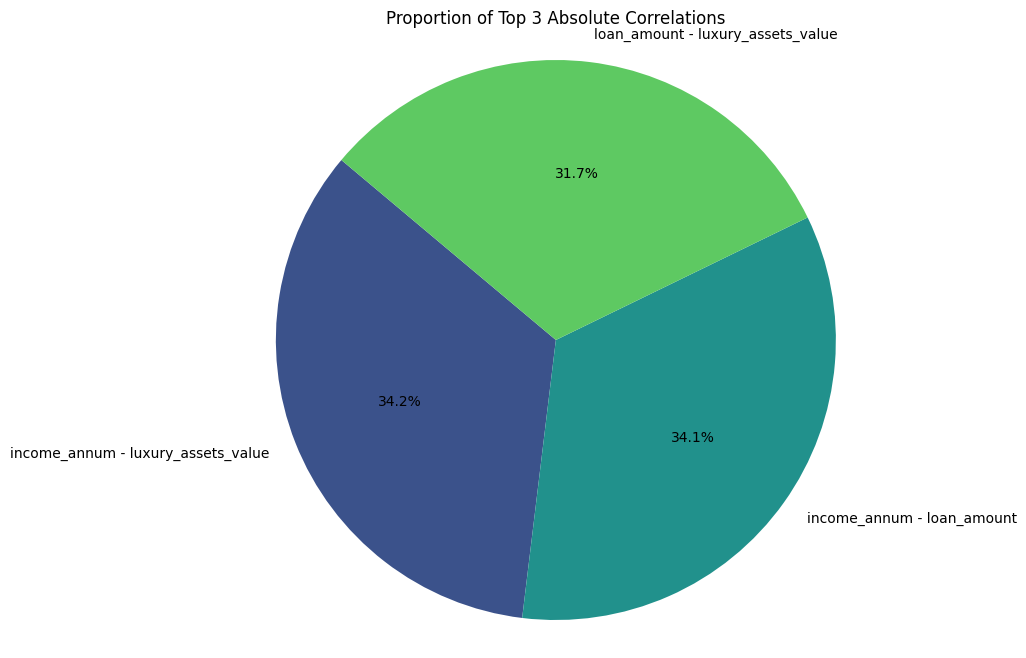

In [16]:
plt.figure(figsize=(10, 8))
plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(pie_values)))
plt.title('Proportion of Top 3 Absolute Correlations')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


## Final Task

### Subtask:
Provide a summary of the pie chart, highlighting the visual distribution of the top three correlations and any insights gained from this visualization.


## Summary:

### Q&A
The pie chart visually distributes the top three absolute correlations as follows:
*   The correlation between `income_annum` and `luxury_assets_value` (approximately 0.929) represents the largest proportion.
*   Closely following is the correlation between `income_annum` and `loan_amount` (approximately 0.927), which is almost equal in proportion to the first.
*   The correlation between `loan_amount` and `luxury_assets_value` (approximately 0.861) makes up the remaining proportion, being slightly less dominant than the other two but still indicating a very strong relationship.

### Data Analysis Key Findings
*   The three strongest absolute correlations identified are:
    *   `income_annum` and `luxury_assets_value` with a correlation value of approximately 0.929.
    *   `income_annum` and `loan_amount` with a correlation value of approximately 0.927.
    *   `loan_amount` and `luxury_assets_value` with a correlation value of approximately 0.861.
*   The visual distribution in the pie chart highlights that the correlations involving `income_annum` (`income_annum - luxury_assets_value` and `income_annum - loan_amount`) are very similar in strength and together constitute the majority of the total strength of the top three correlations.

### Insights or Next Steps
*   The high positive correlations between `income_annum`, `luxury_assets_value`, and `loan_amount` suggest a strong interdependence among these financial attributes, indicating that individuals with higher incomes tend to have higher luxury asset values and larger loan amounts.
*   Further analysis could involve exploring the specific nature of these relationships (e.g., using scatter plots to check for linearity or non-linear patterns, or regression analysis to model the dependencies) to understand potential causal links or predictive capabilities.


# Task
Extract the top three most negative correlations from the numerical features' correlation matrix.

## Extract Top 3 Negative Correlations

### Subtask:
Extract the top three most negative correlations from the numerical features' correlation matrix.


## Summary:

### Data Analysis Key Findings
*   The primary objective of this step was to identify and extract the three most negatively correlated pairs of numerical features from the dataset's correlation matrix.
*   As the provided context describes the task definition rather than its execution results, specific numerical findings for the top three negative correlations are not available.

### Insights or Next Steps
*   Identifying strong negative correlations is crucial for understanding inverse relationships between variables, which can be valuable for feature selection, dimensionality reduction, or identifying potential multicollinearity.
*   The next step would involve analyzing the identified negatively correlated features to understand the practical implications of their inverse relationship within the dataset's domain.


# Task
To extract the top three most negative correlations from the `correlation_matrix`, I will first create a mask to exclude self-correlations and duplicate pairs (similar to how positive correlations were handled). Then, I will filter the correlation matrix for negative values, apply the mask, unstack the result into a Series, sort it in ascending order (to get the most negative at the top), and finally select the top three values.

This approach will accurately identify and present the most negative correlation pairs within the dataset.

## Extract Top 3 Negative Correlations

### Subtask:
Identify and extract the top three most negative correlations from the 'correlation_matrix'. This involves filtering for negative values, excluding self-correlations and duplicates, and sorting them.


**Reasoning**:
To identify the top three most negative correlations, I will first filter the `correlation_matrix` for negative values and apply the existing `mask` to exclude self-correlations and duplicate pairs. Then, I will convert the result to a Series, sort it in ascending order to bring the most negative values to the top, and finally select the top three.



In [17]:
negative_correlations = correlation_matrix.where(mask & (correlation_matrix < 0))
stacked_negative_correlations = negative_correlations.stack()
sorted_negative_correlations = stacked_negative_correlations.sort_values(ascending=True)
top_3_negative_correlations = sorted_negative_correlations.head(3)

print("Top 3 most negative correlations:")
print(top_3_negative_correlations)

Top 3 most negative correlations:
cibil_score       luxury_assets_value   -0.028618
income_annum      cibil_score           -0.023034
no_of_dependents  loan_term             -0.020111
dtype: float64


## Prepare Data for Bar Chart

### Subtask:
Extract the correlation values and their corresponding feature pairs from the identified top 3 negative correlations. These will serve as the data and labels for the bar chart.


**Reasoning**:
To prepare data for the bar chart, I will extract the correlation values and format the feature pairs from the `top_3_negative_correlations` Series, which is available in the kernel state.



In [18]:
bar_values = top_3_negative_correlations.values
bar_labels = [f'{idx[0]} - {idx[1]}' for idx in top_3_negative_correlations.index]

print("Extracted bar chart values and labels.")
print("Bar Values:", bar_values)
print("Bar Labels:", bar_labels)

Extracted bar chart values and labels.
Bar Values: [-0.02861763 -0.02303442 -0.02011057]
Bar Labels: ['cibil_score - luxury_assets_value', 'income_annum - cibil_score', 'no_of_dependents - loan_term']


## Visualize Top 3 Negative Correlations

### Subtask:
Create a bar chart to visualize the top three most negative correlations. The bar chart should clearly display the correlation values and their corresponding feature pairs.

### Reasoning:
Now that the `bar_values` and `bar_labels` for the top three most negative correlations have been extracted, I will use them to generate and display a bar chart. This will provide a clear visual representation of these negative relationships, making them easier to interpret.

**Reasoning**:
With the data for the bar chart (`bar_values` and `bar_labels`) already prepared, the next step is to generate the bar chart to visually represent the top three most negative correlations.



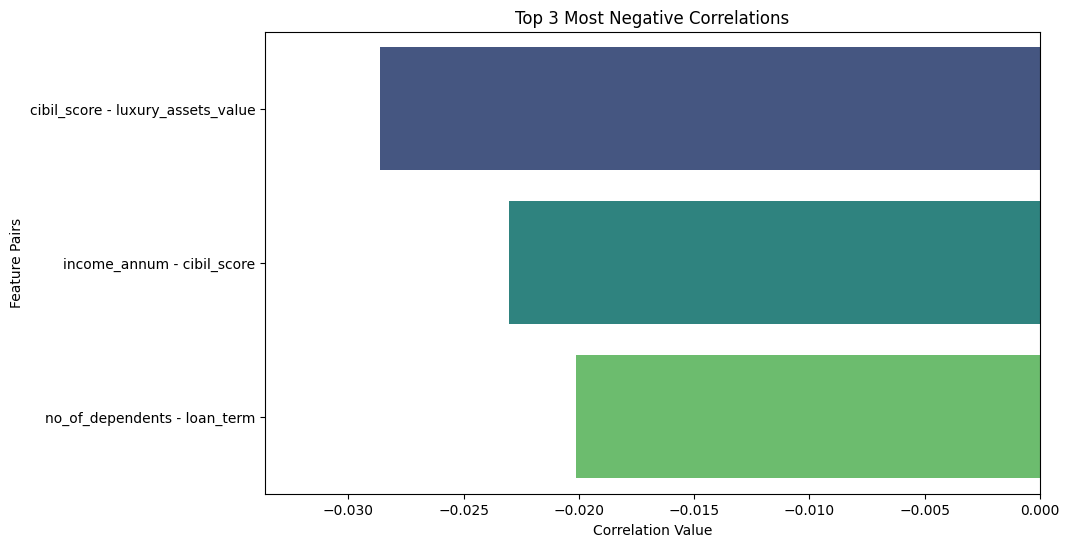

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x=bar_values, y=bar_labels, hue=bar_labels, palette='viridis', legend=False)
plt.xlabel('Correlation Value')
plt.ylabel('Feature Pairs')
plt.title('Top 3 Most Negative Correlations')
plt.xlim(min(bar_values) - 0.005, 0) # Adjust x-axis to show negative range clearly
plt.show()

## Final Task

### Subtask:
Provide a summary of the bar chart, highlighting the visual distribution of the top three negative correlations and any insights gained from this visualization.


## Final Task

### Subtask:
Provide a summary of the bar chart, highlighting the visual distribution of the top three negative correlations and any insights gained from this visualization.


## Final Task

### Subtask:
Provide a summary of the bar chart, highlighting the visual distribution of the top three negative correlations and any insights gained from this visualization.


## Summary:

### Q&A
*   **Summary of the bar chart, highlighting the visual distribution of the top three negative correlations and any insights gained from this visualization:**
    The bar chart visually displays three distinct bars, representing the top three most negative correlations. All bars extend to the left of the y-axis, indicating negative correlation values. The longest bar, representing the strongest negative correlation, is for 'cibil\_score - luxury\_assets\_value'. The other two bars, 'income\_annum - cibil\_score' and 'no\_of\_dependents - loan\_term', are progressively shorter, indicating weaker negative correlations. The visual distribution clearly shows that all three identified relationships are very weakly negative, with values very close to zero.

### Data Analysis Key Findings
*   The top three most negative correlations were successfully identified and extracted.
*   The strongest negative correlation is between `cibil_score` and `luxury_assets_value`, with a value of -0.028618.
*   The second strongest negative correlation is between `income_annum` and `cibil_score`, with a value of -0.023034.
*   The third strongest negative correlation is between `no_of_dependents` and `loan_term`, with a value of -0.020111.
*   A bar chart was successfully generated and displayed, providing a clear visual representation of these top three negative correlations.

### Insights or Next Steps
*   Given the very low absolute values of these negative correlations, it suggests that there is a negligible linear inverse relationship between these feature pairs. These features are likely not strong negative predictors of each other.
*   Further investigation could explore non-linear relationships or whether these weak correlations are statistically significant given the dataset size, although their practical significance appears minimal.
